In [19]:
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss

# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

num_dimensions = 50
num_data = 50
noise_magnitude_on_each_point = 1
total_length = 10
# MAKE SURE NUM_FOURIER_ENTRIES IS EVEN
boundary_padding = 6
num_fitting_params = 2

num_fourier_entries = int(jnp.round(num_dimensions * (total_length + boundary_padding)/total_length))
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale = inference_params
        # Nu is fixed
        nu = 1.5
        lognu = jnp.log(nu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))



def rbf_kernel(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * jnp.exp(-1/2 * (r/scale)**2)
    return jnp.where(r > 0, result, result * (1.0 + jitter))



freq_spacing = (total_length + boundary_padding) / num_fourier_entries
freqs = jnp.fft.fftfreq(num_fourier_entries, d=freq_spacing)
omegas = 2 * jnp.pi * freqs

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))




def fft_field_rfft(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    half_amp = raw_average_amplitude_data[:size // 2 + 1]
    pos = (noise[1:size // 2] + 1j * noise[size // 2 + 1:size]) / jnp.sqrt(2)
    half_spectrum = jnp.concatenate([noise[0:1], pos, noise[size // 2:size // 2 + 1]]) * half_amp
    y_data = jnp.fft.irfft(half_spectrum, n=size) * normalization_factor
    return y_data[0:num_dimensions]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]



def fft_field_first_way(noise, inference_params):
    assert noise.shape == omegas.shape
    size = noise.shape[0]
    amplitude_noise_positive_frequencies = (noise[1: size//2] + 1j * noise[size//2 + 1: size])/jnp.sqrt(2)
    amplitude_noise_negative_frequencies = jnp.conj(jnp.flip(amplitude_noise_positive_frequencies))
    amplitude_noise = jnp.concatenate([
        noise[0:1],
        amplitude_noise_positive_frequencies,
        noise[size//2: size//2 + 1],
        amplitude_noise_negative_frequencies
    ])
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    amplitudes = amplitude_noise*raw_average_amplitude_data
    y_data = jnp.real(jnp.fft.ifft(amplitudes)*normalization_factor)
    return y_data[0: num_dimensions]

def fft_field(noise, inference_params):
    return fft_field_hartley(noise, inference_params)

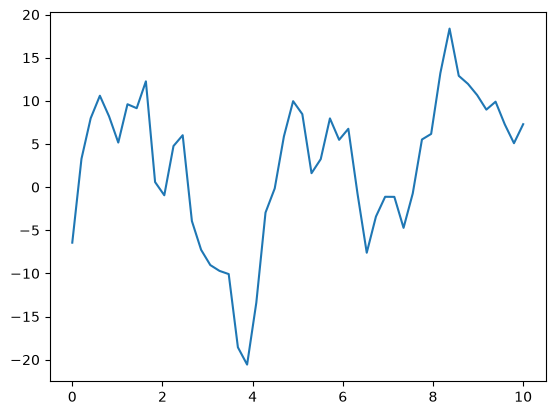

In [20]:
fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
full_fourier_period_linspace = jnp.linspace(0, total_length + boundary_padding, num_fourier_entries)
diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2

cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2, k3, k4 = jr.split(jr.key(96), 4)
#x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
#y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
#y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

#y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

xi = jr.normal(k3, shape = num_fourier_entries)
x_obs = fixed_points_linspace
y_obs_true = fft_field(xi, (4, -1))
y_obs_err = jnp.ones_like(y_obs_true)*noise_magnitude_on_each_point
y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
plt.plot(fixed_points_linspace, y_obs_true)

def response_function(xi, inference_params):
    field_points = fft_field(xi, inference_params)
    return jnp.interp(x_obs, fixed_points_linspace, field_points)

#plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')


In [21]:
def logvarprior(logvar):
    return -0.5*logvar*logvar
def logscaleprior(logscale):
    return -0.5*logscale*logscale
def lognuprior(lognu):
    return -0.5*lognu*lognu
def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)

R = jax.jacobian(response)(fixed_points_linspace)

def negative_logdensity(x):
    logvar = x[0]
    logscale = x[1]
    xi = x[2:]
    inference_params = (logvar, logscale)
    negative_log_p_s = -logvarprior(logvar) - logscaleprior(logscale) + 0.5*xi.T @ xi
    res = y_obs - R @ fft_field(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s




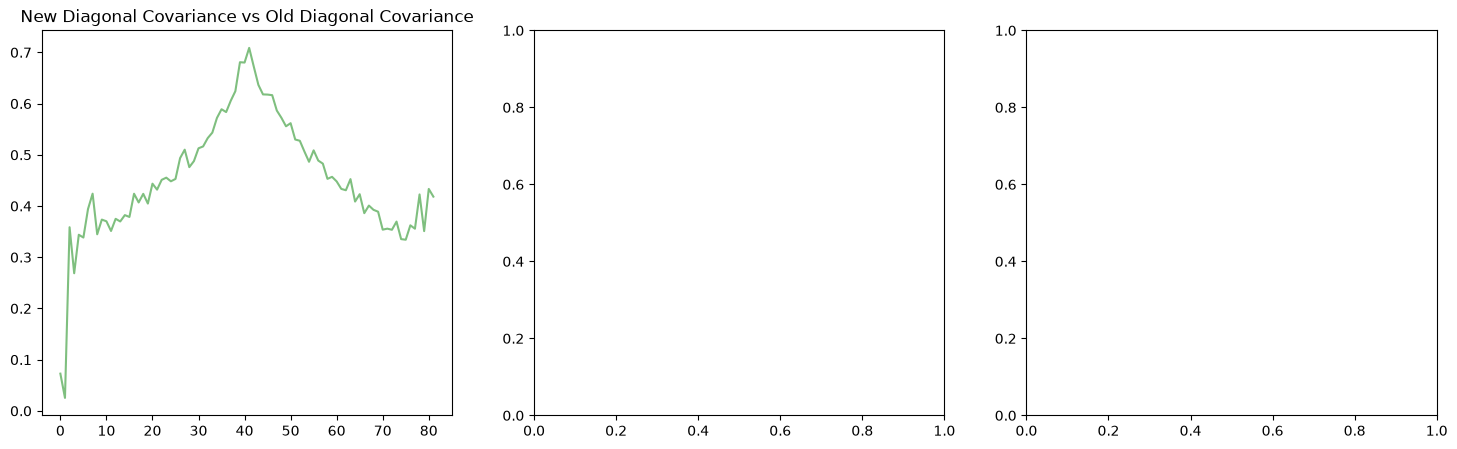

In [ ]:
num_overall_steps = 200000
burn_in = 0
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps=10,
    step_size=0.02,
    inv_mass_matrix = jnp.eye(num_fourier_entries + num_fitting_params),
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(4)
initial_coordinates = jnp.zeros(num_fourier_entries + num_fitting_params)


overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logvars = overall_data_arr[:, 0]
logscales = overall_data_arr[:, 1]
overall_position_arr = overall_data_arr[:, 2:]  
lognus = jnp.zeros_like(logvars)
inference_params = (logvars, logscales)

overall_position_arr = jax.vmap(fft_field, in_axes=(0, 0))(
    overall_position_arr, inference_params
)
overall_position_arr = overall_position_arr[:, 0:num_dimensions]

mean_position = overall_position_arr.sum(axis=0)/num_good_samples

vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
#old_cov = jnp.array(np.load('cov_matrix_fitting_three_parameters_matern.npy'))
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_entries + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")
np.save('cov_matrix_fitting_variance_scale_matern.npy', np.asarray(cov))

[ 1.24375056  1.24375056 42.06229797 ... 60.2389635  53.13177333
 55.35655024]
[0.85103816 0.85103816 0.75367614 ... 0.48478107 0.48716648 0.46668962]


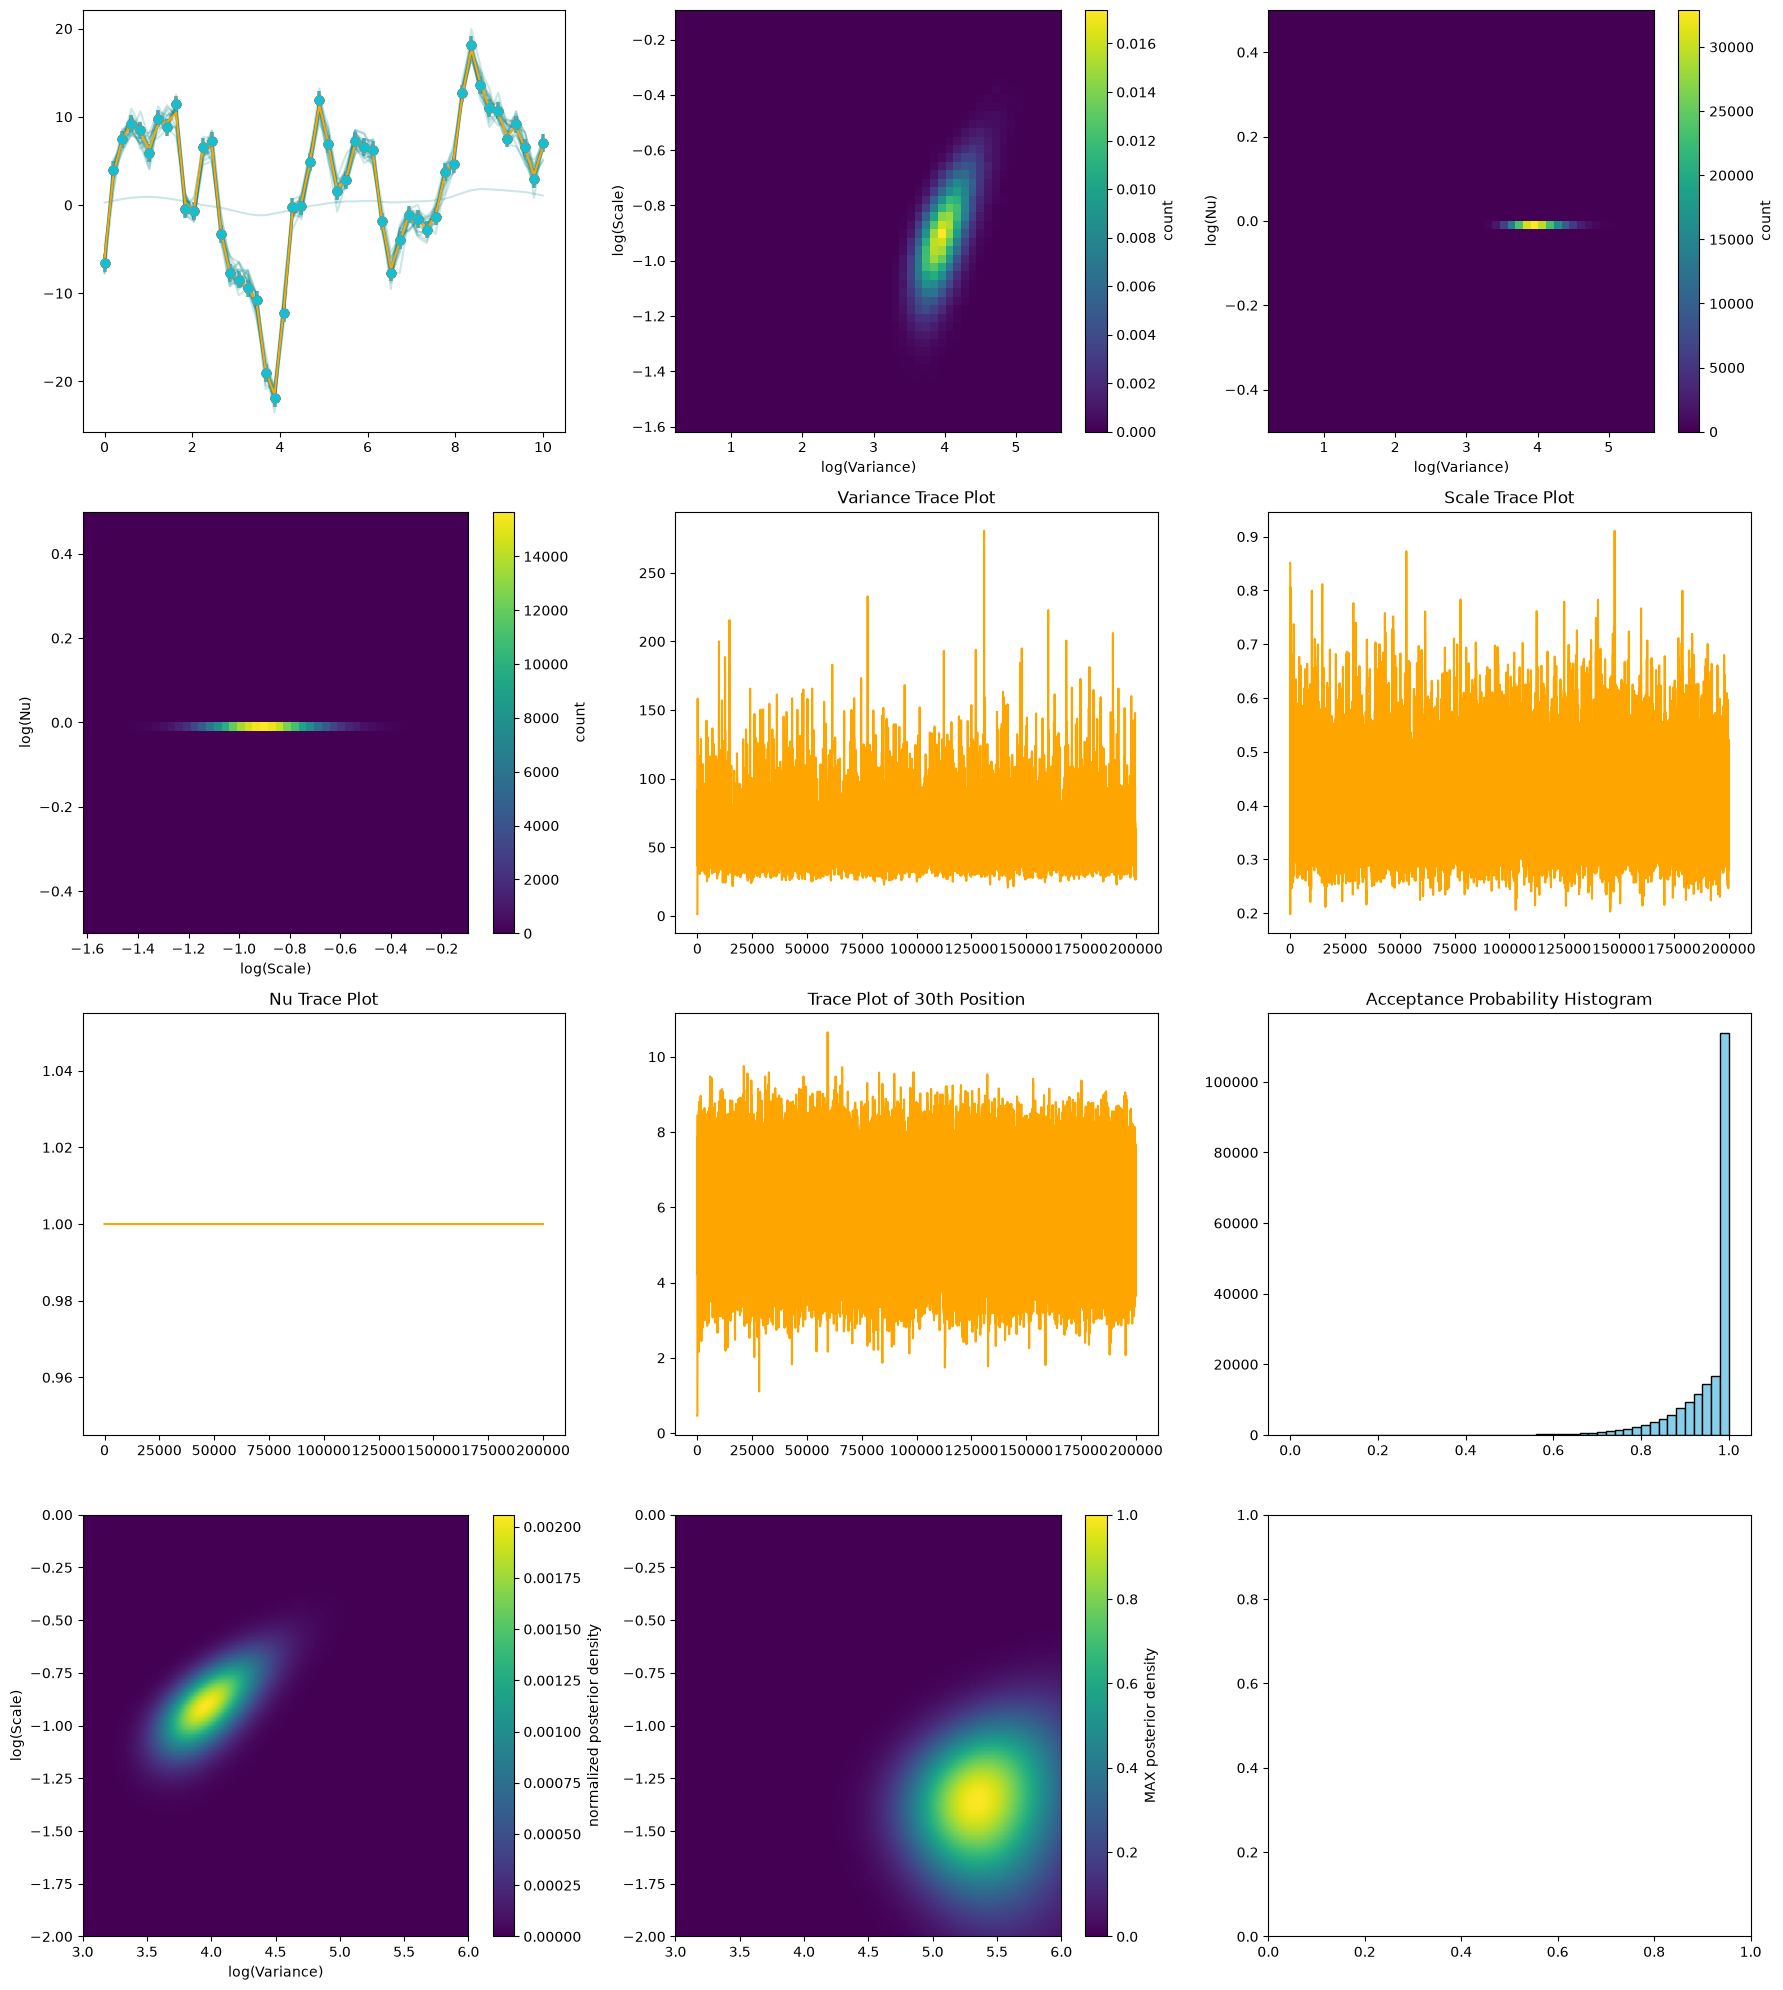

In [23]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
print(vars)
print(scales)
for i in range (0, 20):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[1000*i, :], color = "teal", alpha = 0.2)
    axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
axes[0][0].plot(fixed_points_linspace, mean_position, color = "orange", alpha = 1)


def log_posterior_density(inference_params):
    logvar, logscale = inference_params
    logprior = logvarprior(logvar) + logscaleprior(logscale)
    
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    
    # Add numerical jitter to prevent top-right corner NaNs
    #jitter = 1e-6 * jnp.eye(cov_data_matrix.shape[0])
    jitter = 0
    total_cov_on_data = R @ R.T + cov_data_matrix + jitter
    
    # Cholesky decomposition is much more stable than standard solve/slogdet
    cho_factor = jsp.linalg.cho_factor(total_cov_on_data)
    
    # Solve using Cholesky
    solve_val = jsp.linalg.cho_solve(cho_factor, y_obs)
    log_p_data_given_params = -0.5 * (y_obs @ solve_val)
    
    # Log determinant from Cholesky diagonal: 2 * sum(log(diag(L)))
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(cho_factor[0])))
    
    # RETURN LOG POSTERIOR DIRECTLY (No jnp.exp here!)
    return log_p_data_given_params + logprior - 0.5 * logdet 

def max_log_posterior_density(inference_params):
    log_pd = log_posterior_density(inference_params)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    D = jnp.linalg.inv(jnp.eye(num_fourier_entries) + R.T @ inv_cov_data_matrix @ R)
    _, logdet = jnp.linalg.slogdet(D)
    return log_pd - 0.5*logdet

bins1 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logvars, logscales, bins=bins1)

# bin centers along each axis
x_centers = jnp.linspace(3, 6, 150)
y_centers = jnp.linspace(-2, 0, 100)

# build the grid of (logvar, logscale) center points
# indexing='ij' so X, Y have shape (nx, ny), matching H's shape
X, Y = jnp.meshgrid(x_centers, y_centers, indexing='ij')

# evaluate F at every cell center
# F takes a single (logvar, logscale) tuple, so vmap over the flattened grid
F_vmapped = jax.vmap(lambda lv, ls: log_posterior_density((lv, ls)))
G_vmapped = jax.vmap(lambda lv, ls: max_log_posterior_density((lv, ls)))
Z_flat = F_vmapped(X.ravel(), Y.ravel())
Z2_flat = G_vmapped(X.ravel(), Y.ravel())
Z = Z_flat.reshape(X.shape)  # shape (nx, ny), same layout as H
Z2 = Z2_flat.reshape(X.shape)
Z = jnp.exp(Z - jnp.max(Z))
Z2 = jnp.exp(Z2 - jnp.max(Z2))
Z = Z/jnp.sum(Z)
H = H/jnp.sum(H)

# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[0][1].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][1], label='count')

im = axes[3][0].imshow(
    Z.T,
    origin='lower',
    extent=[x_centers[0], x_centers[-1], y_centers[0], y_centers[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[3][0], label='normalized posterior density')

im = axes[3][1].imshow(
    Z2.T,
    origin='lower',
    extent=[x_centers[0], x_centers[-1], y_centers[0], y_centers[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[3][1], label='MAX posterior density')



bins2 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logvars, lognus, bins=bins2)

# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[0][2].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][2], label='count')

bins3 = 50  # or (nx, ny) tuple for different bin counts per axis
H, xedges, yedges = jnp.histogram2d(logscales, lognus, bins=bins3)

# H has shape (nx, ny); transpose so x is horizontal, y is vertical for imshow
im = axes[1][0].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[1][0], label='count')



axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Scale)")

axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Nu)")

axes[1][0].set_xlabel("log(Scale)")
axes[1][0].set_ylabel("log(Nu)")

axes[3][0].set_xlabel("log(Variance)")
axes[3][0].set_ylabel("log(Scale)")


axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")

axes[1][2].plot(time_arr, scales, color = "Orange")
axes[1][2].set_title("Scale Trace Plot")

axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")

axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")

axes[2][2].set_title("Acceptance Probability Histogram")

axes[2][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

fig.tight_layout()
